#Task 1: Install Required Libraries

In [1]:
!pip install nltk scikit-learn pandas matplotlib seaborn joblib

# Import Libraries

In [2]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib

from nltk.corpus import movie_reviews
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

#Task 2: Data Exploration

**Load Dataset**

In [3]:
documents = []

for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        review = movie_reviews.raw(fileid)
        documents.append((review, category))

df = pd.DataFrame(documents, columns=['review', 'sentiment'])

df.head()

,review,sentiment
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


**Number of Reviews**

In [4]:
print("Total Reviews:", len(df))
print("\nPositive Reviews:")
print(len(df[df['sentiment']=='pos']))

print("\nNegative Reviews:")
print(len(df[df['sentiment']=='neg']))

Total Reviews: 2000

Positive Reviews:
1000

Negative Reviews:
1000


**Class Distribution Graph**

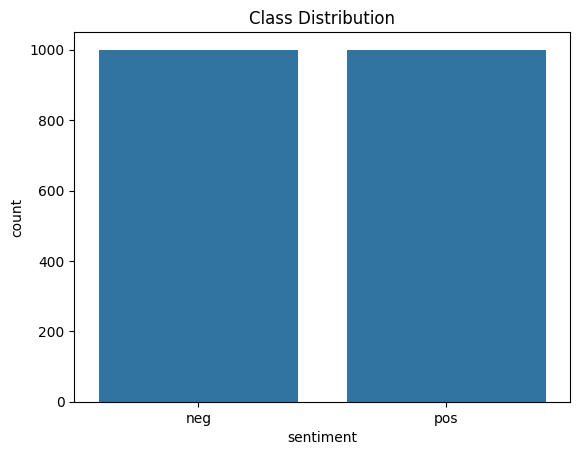

In [5]:
sns.countplot(x='sentiment', data=df)
plt.title("Class Distribution")
plt.show()

**Five Positive Reviews**

In [6]:
for i,text in enumerate(df[df['sentiment']=='pos']['review'].head()):
    print(f"\nPositive Review {i+1}\n")
    print(text[:500])


Positive Review 1

films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
for starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid '80s with a 12-part series called the watchmen . 
to say moore and campbell thoroughly researched the subject

Positive Review 2

every now and then a movie comes along from a suspect studio , with every indication that it will be a stinker , and to everybody's surprise ( perhaps even the studio ) the film becomes a critical darling . 
mtv films' _election , a high school comedy starring matthew broderick and reese witherspoon , is a current example . 
did anybody know this film existed a week before it opened ? 
the plot is deceptively simple . 
george washington carver high school

**Five Negative Reviews**

In [7]:
for i,text in enumerate(df[df['sentiment']=='neg']['review'].head()):
    print(f"\nNegative Review {i+1}\n")
    print(text[:500])


Negative Review 1

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt

Negative Review 2

the happy bastard's quick movie review 
damn that y2k bug . 
it's got a head start in this movie starring jamie lee curtis and another baldwin brother ( william this time ) in a story regarding a crew of a tugboat that comes across a deserted russian tech ship that has a strangeness to it when they kick the power back on . 
little do they know the power within . . . 
going for the gore and bringing on a few action sequences here and there , virus still fe

# Task 3: NLP Preprocessing Pipeline

**Preprocessing Function**

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'[^\w\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

**Show Each Step**

In [9]:
sample_review = df['review'][0]

print("ORIGINAL REVIEW:\n")
print(sample_review[:500])

ORIGINAL REVIEW:

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt


**Lowercase**

In [10]:
lowercase = sample_review.lower()

print(lowercase[:500])

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt


**Remove Punctuation**

In [11]:
punct_removed = re.sub(r'[^\w\s]', '', lowercase)

print(punct_removed[:500])

plot  two teen couples go to a church party  drink and then drive  
they get into an accident  
one of the guys dies  but his girlfriend continues to see him in her life  and has nightmares  
whats the deal  
watch the movie and  sorta  find out    
critique  a mindfuck movie for the teen generation that touches on a very cool idea  but presents it in a very bad package  
which is what makes this review an even harder one to write  since i generally applaud films which attempt to break the mold 


**Tokenization**

In [14]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [15]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [16]:
tokens = word_tokenize(punct_removed)

print(tokens[:50])

['plot', 'two', 'teen', 'couples', 'go', 'to', 'a', 'church', 'party', 'drink', 'and', 'then', 'drive', 'they', 'get', 'into', 'an', 'accident', 'one', 'of', 'the', 'guys', 'dies', 'but', 'his', 'girlfriend', 'continues', 'to', 'see', 'him', 'in', 'her', 'life', 'and', 'has', 'nightmares', 'whats', 'the', 'deal', 'watch', 'the', 'movie', 'and', 'sorta', 'find', 'out', 'critique', 'a', 'mindfuck', 'movie']


In [17]:
tokens = punct_removed.split()

print(tokens[:50])

['plot', 'two', 'teen', 'couples', 'go', 'to', 'a', 'church', 'party', 'drink', 'and', 'then', 'drive', 'they', 'get', 'into', 'an', 'accident', 'one', 'of', 'the', 'guys', 'dies', 'but', 'his', 'girlfriend', 'continues', 'to', 'see', 'him', 'in', 'her', 'life', 'and', 'has', 'nightmares', 'whats', 'the', 'deal', 'watch', 'the', 'movie', 'and', 'sorta', 'find', 'out', 'critique', 'a', 'mindfuck', 'movie']


**Stop Word Removal**

In [19]:
filtered = [word for word in tokens if word not in stop_words]

print(filtered[:50])

['plot', 'two', 'teen', 'couples', 'go', 'church', 'party', 'drink', 'drive', 'get', 'accident', 'one', 'guys', 'dies', 'girlfriend', 'continues', 'see', 'life', 'nightmares', 'whats', 'deal', 'watch', 'movie', 'sorta', 'find', 'critique', 'mindfuck', 'movie', 'teen', 'generation', 'touches', 'cool', 'idea', 'presents', 'bad', 'package', 'makes', 'review', 'even', 'harder', 'one', 'write', 'since', 'generally', 'applaud', 'films', 'attempt', 'break', 'mold', 'mess']


**Lemmatization**

In [20]:
lemmatized = [lemmatizer.lemmatize(word) for word in filtered]

print(lemmatized[:50])

['plot', 'two', 'teen', 'couple', 'go', 'church', 'party', 'drink', 'drive', 'get', 'accident', 'one', 'guy', 'dy', 'girlfriend', 'continues', 'see', 'life', 'nightmare', 'whats', 'deal', 'watch', 'movie', 'sorta', 'find', 'critique', 'mindfuck', 'movie', 'teen', 'generation', 'touch', 'cool', 'idea', 'present', 'bad', 'package', 'make', 'review', 'even', 'harder', 'one', 'write', 'since', 'generally', 'applaud', 'film', 'attempt', 'break', 'mold', 'mess']


**Apply Preprocessing**

In [21]:
df['clean_review'] = df['review'].apply(preprocess_text)

df.head()

,review,sentiment,clean_review
0,"plot : two teen couples go to a church party ,...",neg,plot two teen couple go church party drink dri...
1,the happy bastard's quick movie review \ndamn ...,neg,happy bastard quick movie review damn y2k bug ...
2,it is movies like these that make a jaded movi...,neg,movie like make jaded movie viewer thankful in...
3,""" quest for camelot "" is warner bros . ' firs...",neg,quest camelot warner bros first featurelength ...
4,synopsis : a mentally unstable man undergoing ...,neg,synopsis mentally unstable man undergoing psyc...


#Task 4: Feature Extraction

**Part A: Bag of Words**

In [22]:
bow_vectorizer = CountVectorizer(max_features=5000)

X_bow = bow_vectorizer.fit_transform(df['clean_review'])

print("Vocabulary Size:", len(bow_vectorizer.vocabulary_))

print("\nSample Vocabulary:")
print(list(bow_vectorizer.vocabulary_.keys())[:20])

print("\nFeature Matrix Shape:")
print(X_bow.shape)

Vocabulary Size: 5000

Sample Vocabulary:
['plot', 'two', 'teen', 'couple', 'go', 'church', 'party', 'drink', 'drive', 'get', 'accident', 'one', 'guy', 'dy', 'girlfriend', 'continues', 'see', 'life', 'nightmare', 'whats']

Feature Matrix Shape:
(2000, 5000)


**Part B: TF-IDF**

In [23]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf_vectorizer.fit_transform(df['clean_review'])

print("Vocabulary Size:", len(tfidf_vectorizer.vocabulary_))

print("\nSample Vocabulary:")
print(list(tfidf_vectorizer.vocabulary_.keys())[:20])

print("\nFeature Matrix Shape:")
print(X_tfidf.shape)

Vocabulary Size: 5000

Sample Vocabulary:
['plot', 'two', 'teen', 'couple', 'go', 'church', 'party', 'drink', 'drive', 'get', 'accident', 'one', 'guy', 'dy', 'girlfriend', 'continues', 'see', 'life', 'nightmare', 'whats']

Feature Matrix Shape:
(2000, 5000)


#Task 5: Model Training

**Labels**

In [24]:
y = df['sentiment']

**Train-Test Split**

In [25]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow,
    y,
    test_size=0.2,
    random_state=42
)

X_train_tfidf, X_test_tfidf, y_train2, y_test2 = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

**Train BoW Model**

In [26]:
bow_model = LogisticRegression(max_iter=1000)

bow_model.fit(X_train_bow,y_train)

LogisticRegression(max_iter=1000)

**Train TF-IDF Model**

In [27]:
tfidf_model = LogisticRegression(max_iter=1000)

tfidf_model.fit(X_train_tfidf,y_train2)

LogisticRegression(max_iter=1000)

**Save Models**

In [28]:
joblib.dump(bow_model,'bow_model.pkl')
joblib.dump(tfidf_model,'tfidf_model.pkl')

['tfidf_model.pkl']

#Task 6: Evaluation

**BoW**

In [29]:
bow_pred = bow_model.predict(X_test_bow)

bow_accuracy = accuracy_score(y_test,bow_pred)
bow_precision = precision_score(y_test,bow_pred,pos_label='pos')
bow_recall = recall_score(y_test,bow_pred,pos_label='pos')
bow_f1 = f1_score(y_test,bow_pred,pos_label='pos')

**TF-IDF**

In [30]:
tfidf_pred = tfidf_model.predict(X_test_tfidf)

tfidf_accuracy = accuracy_score(y_test2,tfidf_pred)
tfidf_precision = precision_score(y_test2,tfidf_pred,pos_label='pos')
tfidf_recall = recall_score(y_test2,tfidf_pred,pos_label='pos')
tfidf_f1 = f1_score(y_test2,tfidf_pred,pos_label='pos')

**Comparison Table**

In [31]:
results = pd.DataFrame({

'Metric':['Accuracy','Precision','Recall','F1 Score'],

'BoW':[
bow_accuracy,
bow_precision,
bow_recall,
bow_f1
],

'TF-IDF':[
tfidf_accuracy,
tfidf_precision,
tfidf_recall,
tfidf_f1
]

})

print(results)

      Metric       BoW    TF-IDF
0   Accuracy  0.827500  0.830000
1  Precision  0.823529  0.830846
2     Recall  0.835821  0.830846
3   F1 Score  0.829630  0.830846


**Confusion Matrix**

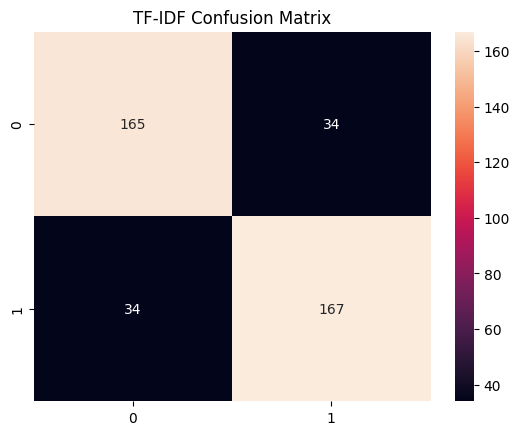

In [32]:
cm = confusion_matrix(y_test2,tfidf_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title("TF-IDF Confusion Matrix")
plt.show()

#Task 7: Feature Importance

In [33]:
feature_names = tfidf_vectorizer.get_feature_names_out()

coefficients = tfidf_model.coef_[0]

top_positive = np.argsort(coefficients)[-10:]

top_negative = np.argsort(coefficients)[:10]

**Positive Words**

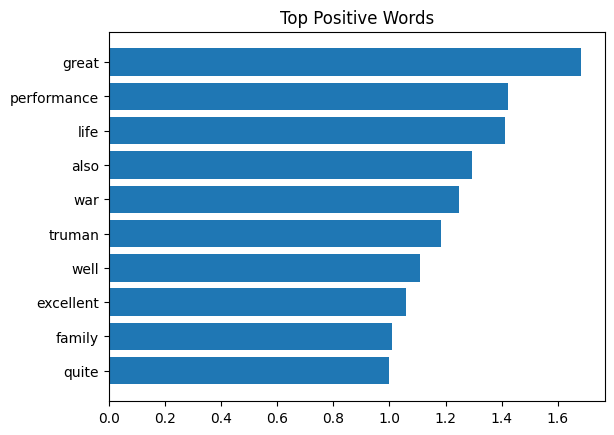

In [34]:
positive_words = feature_names[top_positive]

positive_scores = coefficients[top_positive]

plt.barh(positive_words,positive_scores)

plt.title("Top Positive Words")

plt.show()

**Negative Words**

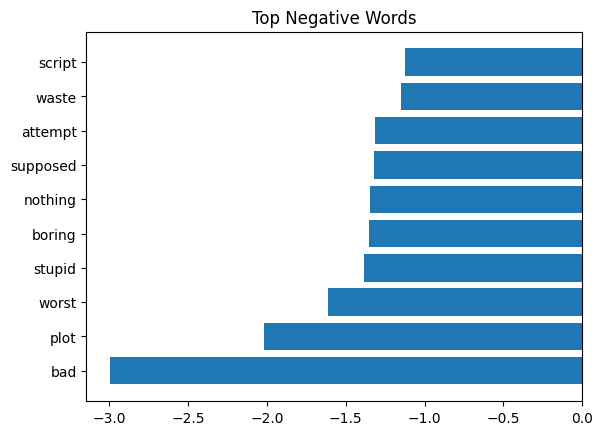

In [35]:
negative_words = feature_names[top_negative]

negative_scores = coefficients[top_negative]

plt.barh(negative_words,negative_scores)

plt.title("Top Negative Words")

plt.show()

#Task 8: Custom Review Prediction

In [36]:
reviews = [

"This movie was absolutely amazing and inspiring",

"I hated this movie it was boring",

"The acting was fantastic",

"The film was terrible and disappointing",

"An excellent masterpiece with great direction"

]

In [37]:
for review in reviews:

    clean = preprocess_text(review)

    vector = tfidf_vectorizer.transform([clean])

    prediction = tfidf_model.predict(vector)[0]

    probability = max(tfidf_model.predict_proba(vector)[0])

    print("\nReview:",review)

    print("Prediction:",prediction)

    print("Confidence:",round(probability*100,2),"%")


Review: This movie was absolutely amazing and inspiring
Prediction: pos
Confidence: 53.36 %

Review: I hated this movie it was boring
Prediction: neg
Confidence: 71.32 %

Review: The acting was fantastic
Prediction: pos
Confidence: 54.03 %

Review: The film was terrible and disappointing
Prediction: neg
Confidence: 69.97 %

Review: An excellent masterpiece with great direction
Prediction: pos
Confidence: 82.29 %


#Task 9: Comparative Analysis Report

TF-IDF performed better than Bag of Words because it not only counts word
frequency but also considers the importance of words across the entire dataset. Common words receive lower weights while unique and informative words receive higher weights. This helps the model focus on meaningful terms for sentiment prediction.

Bag of Words is simple and computationally efficient. It is easy to implement and works well on many text classification tasks. However, it treats all words equally and does not consider the importance of words within the dataset.


TF-IDF reduces the impact of frequently occurring words and highlights discriminative terms. This often leads to better classification performance. However, it requires slightly more computation and memory than Bag of Words.


For real-world sentiment analysis applications, TF-IDF is generally recommended because it produces more informative features and typically achieves higher accuracy.